In [1]:
import pandas as pd
import geopandas as geopd
import os

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

In [2]:
path = "/home/iielse/Documents/GIS-sync/perusdata/bedrock_of_finland_1m_epsg3067_gdb/bedrock_of_finland_1m.gdb"
classes = {
    "carbonate_sedimentary": [2122],
    "siliclastic_sedimentary": [2121],
    "volcanic": [2112],
    "hypabyssal": [2113],
    "plutonic": [2111],
    "metamorphic": [213, 2133, 2134, 2135],
    "other_rock" :[2114, 2123, 2136] 
    } # Check that your data source has the same classification
columns = [f"{key}_perc" for key in classes]


In [3]:
litho = geopd.read_file(path, layer='br1m_lithological_unit')

/home/iielse/miniforge3/envs/geo/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


<Axes: >

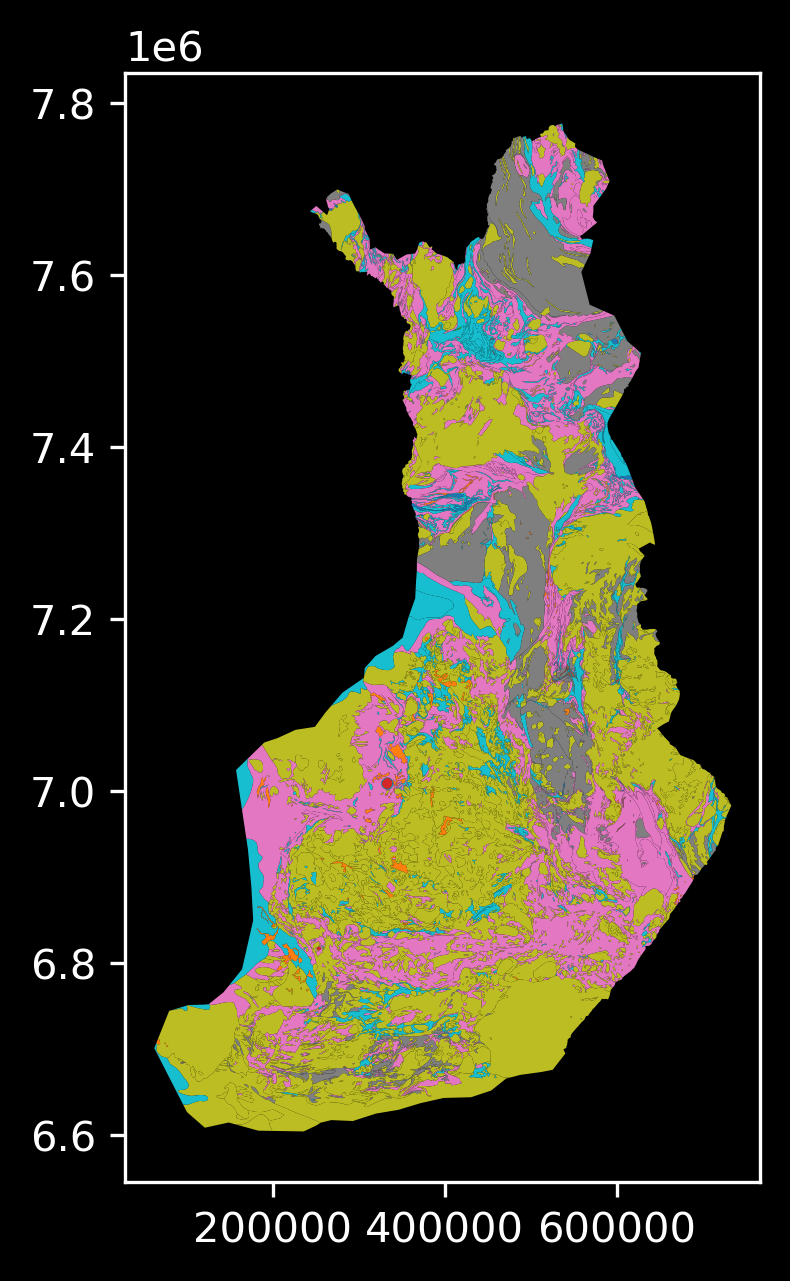

In [4]:
litho.plot('ROCK_CLASS_')

In [5]:
catchments_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_catchment_boundaries.gpkg'
catchments = geopd.read_file(catchments_path, layer='catchments')

In [6]:
catchments

,gauge_id,area,geometry
0,996,3081,"MULTIPOLYGON (((381230 7007980, 381230 7007970..."
1,1003,2160,"MULTIPOLYGON (((461570 7052380, 461590 7052380..."
2,1008,5768,"MULTIPOLYGON (((461570 7052380, 461590 7052380..."
3,1009,5971,"MULTIPOLYGON (((461570 7052380, 461590 7052380..."
4,1012,6889,"MULTIPOLYGON (((459810 6911040, 459810 6911030..."
...,...,...,...
315,961,2073,"MULTIPOLYGON (((589840 7022170, 589850 7022170..."
316,964,449,"MULTIPOLYGON (((533340 6927940, 533340 6927930..."
317,1369,202,"MULTIPOLYGON (((494639.907 7381090.953, 494659..."
318,1366,399,"MULTIPOLYGON (((488929.91 7356740.681, 488949...."


In [10]:
pbar = tqdm(catchments.iterrows(), total=len(catchments))

for i, watershed in pbar:
    pbar.set_description(f"Processing catchment {i}")
    # Changing to GeoDataFrame
    watershed = geopd.GeoDataFrame(
                    dict(zip(list(watershed.index), list(watershed.values))),
                    crs=catchments.crs, geometry='geometry', index=[0])
    
    minx = watershed.bounds.at[0, 'minx']
    miny = watershed.bounds.at[0, 'miny']
    maxx = watershed.bounds.at[0, 'maxx']
    maxy = watershed.bounds.at[0, 'maxy']

    rock = geopd.read_file(path, bbox=(minx, miny, maxx, maxy), layer='br1m_lithological_unit')
    rock = rock.clip(watershed, keep_geom_type=True)
    # There is rock data
    if len(rock) > 0:
        for rock_class in classes:
            # Classifying into given classes
            rock.loc[rock["ROCK_CLASS"].isin(classes[rock_class]), "rock_class"] = rock_class
            
        rock = rock.dissolve(by="rock_class", as_index=False)
        watershed_area = watershed.area.sum()
            
        for rock_class in classes:
            rock_class_area = rock[rock["rock_class"] == rock_class].area.sum()
            # multiplying by 100 to get percentage
            catchments.at[i, f"{rock_class}_perc"] = round((rock_class_area / watershed_area) * 100, 4)

    # Handling nodata situation
    else:
        for rock_class in classes:
            catchments.at[i, f"{soil_class}_perc"] = 0

  0%|          | 0/320 [00:00<?, ?it/s]

/home/iielse/miniforge3/envs/geo/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'bedrock_of_finland_1m.gdb': 'br1m_lithological_unit' (default), 'br1m_meteorite_impact', 'br1m_dyke_swarm', 'br1m_tectonic_province', 'br1m_form_line', 'br1m_structural_line', 'br1m_kimberlite'. Specify layer parameter to avoid this warning.
  result = read_func(
/home/iielse/miniforge3/envs/geo/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'bedrock_of_finland_1m.gdb': 'br1m_lithological_unit' (default), 'br1m_meteorite_impact', 'br1m_dyke_swarm', 'br1m_tectonic_province', 'br1m_form_line', 'br1m_structural_line', 'br1m_kimberlite'. Specify layer parameter to avoid this warning.
  result = read_func(
/home/iielse/miniforge3/envs/geo/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'bedrock_of_finland_1m.gdb': 'br1m_lithological_unit' (default), 'br1m_meteorite

In [11]:
catchments

,gauge_id,area,geometry,carbonate_sedimentary_perc,siliclastic_sedimentary_perc,volcanic_perc,hypabyssal_perc,plutonic_perc,metamorphic_perc,other_rock_perc
0,996,3081,"MULTIPOLYGON (((381230 7007980, 381230 7007970...",0.0,0.0000,0.9640,5.3890,92.8083,0.8388,0.0
1,1003,2160,"MULTIPOLYGON (((461570 7052380, 461590 7052380...",0.0,9.7190,16.8545,0.1422,58.9784,14.3060,0.0
2,1008,5768,"MULTIPOLYGON (((461570 7052380, 461590 7052380...",0.0,3.8667,9.8430,0.0532,62.1058,24.1312,0.0
3,1009,5971,"MULTIPOLYGON (((461570 7052380, 461590 7052380...",0.0,3.7353,9.5086,0.0514,63.3934,23.3113,0.0
4,1012,6889,"MULTIPOLYGON (((459810 6911040, 459810 6911030...",0.0,3.2375,8.8844,0.0446,65.9664,21.8672,0.0
...,...,...,...,...,...,...,...,...,...,...
315,961,2073,"MULTIPOLYGON (((589840 7022170, 589850 7022170...",0.0,0.0000,0.1578,0.5822,32.7145,66.5454,0.0
316,964,449,"MULTIPOLYGON (((533340 6927940, 533340 6927930...",0.0,0.0000,0.0000,0.0000,36.5544,63.4456,0.0
317,1369,202,"MULTIPOLYGON (((494639.907 7381090.953, 494659...",0.0,0.0000,9.2665,0.0000,8.0436,82.6899,0.0
318,1366,399,"MULTIPOLYGON (((488929.91 7356740.681, 488949....",0.0,0.0000,0.0000,0.0000,35.6025,64.3975,0.0


carbonate_sedimentary
max: 1.8518
mean: 0.0172890625
median: 0.0
min: 0.0


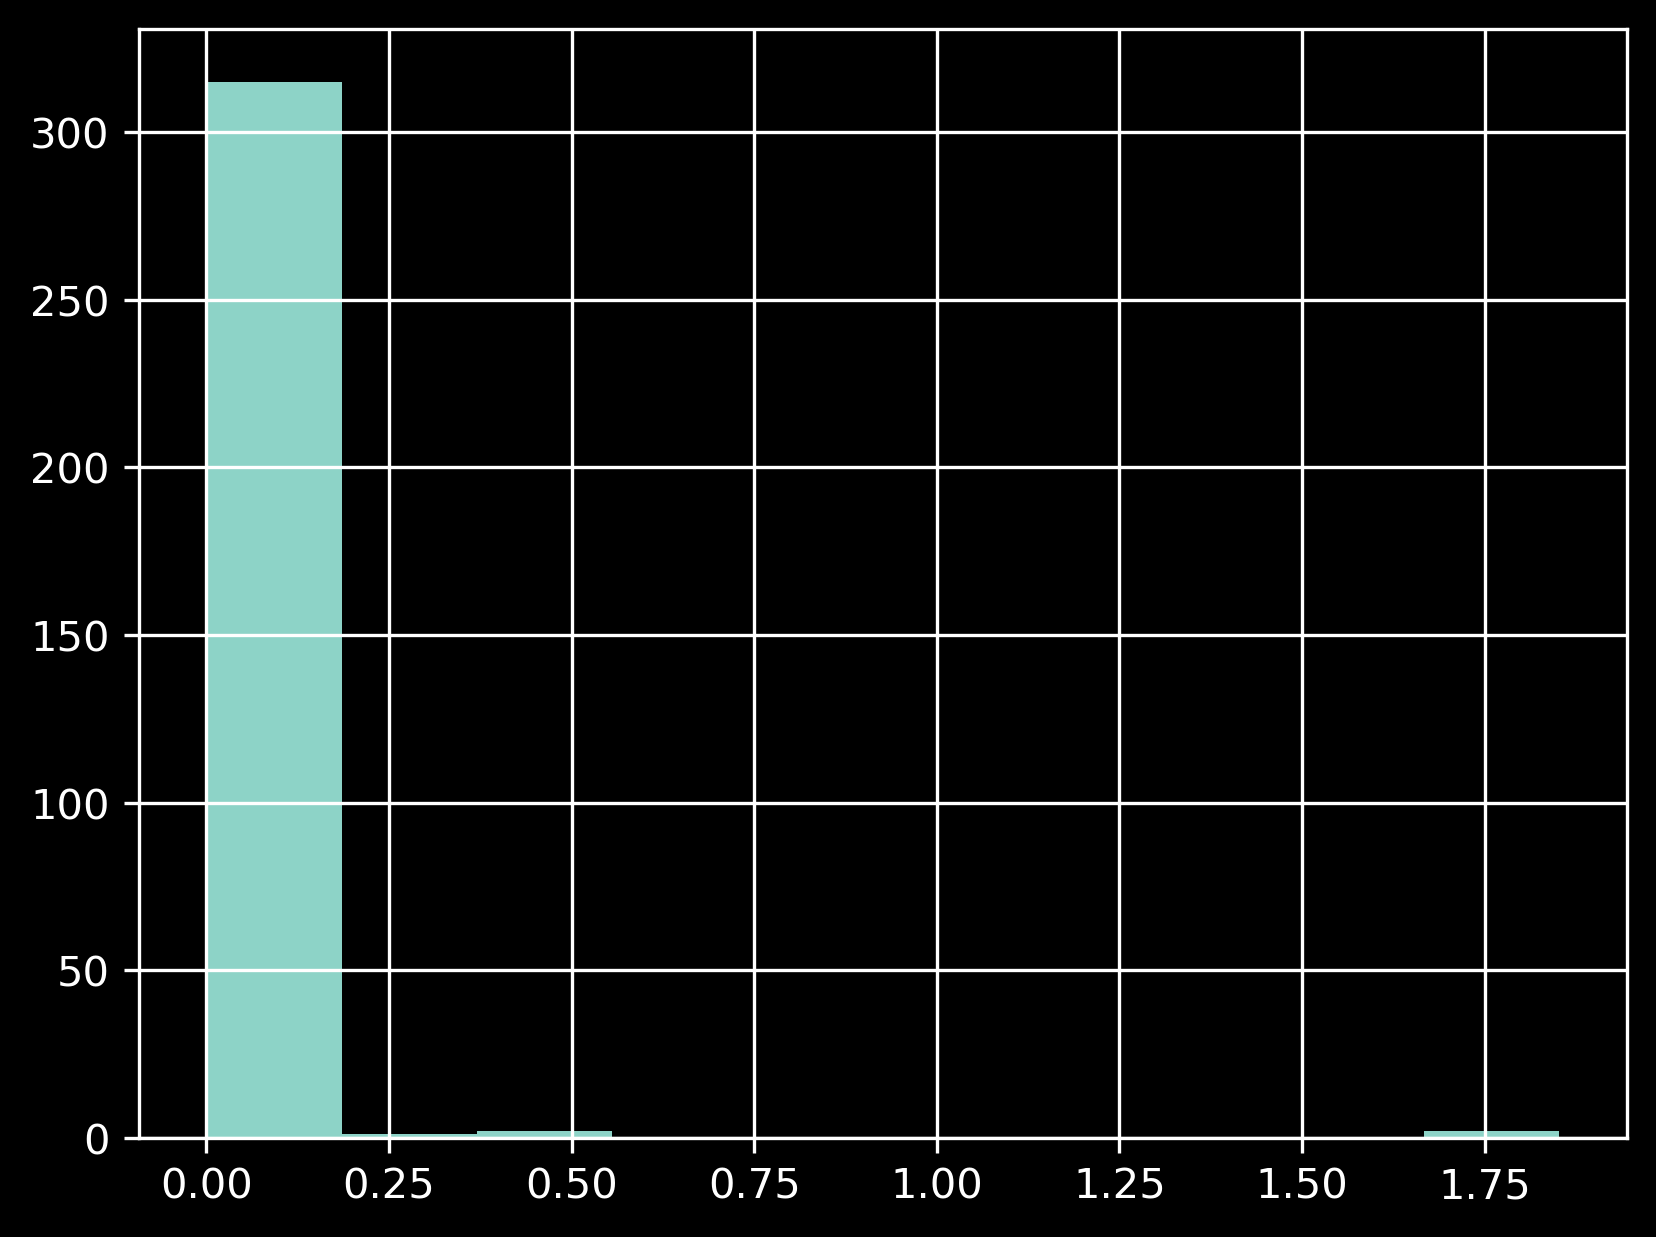

siliclastic_sedimentary
max: 36.0855
mean: 1.6808959375
median: 0.0
min: 0.0


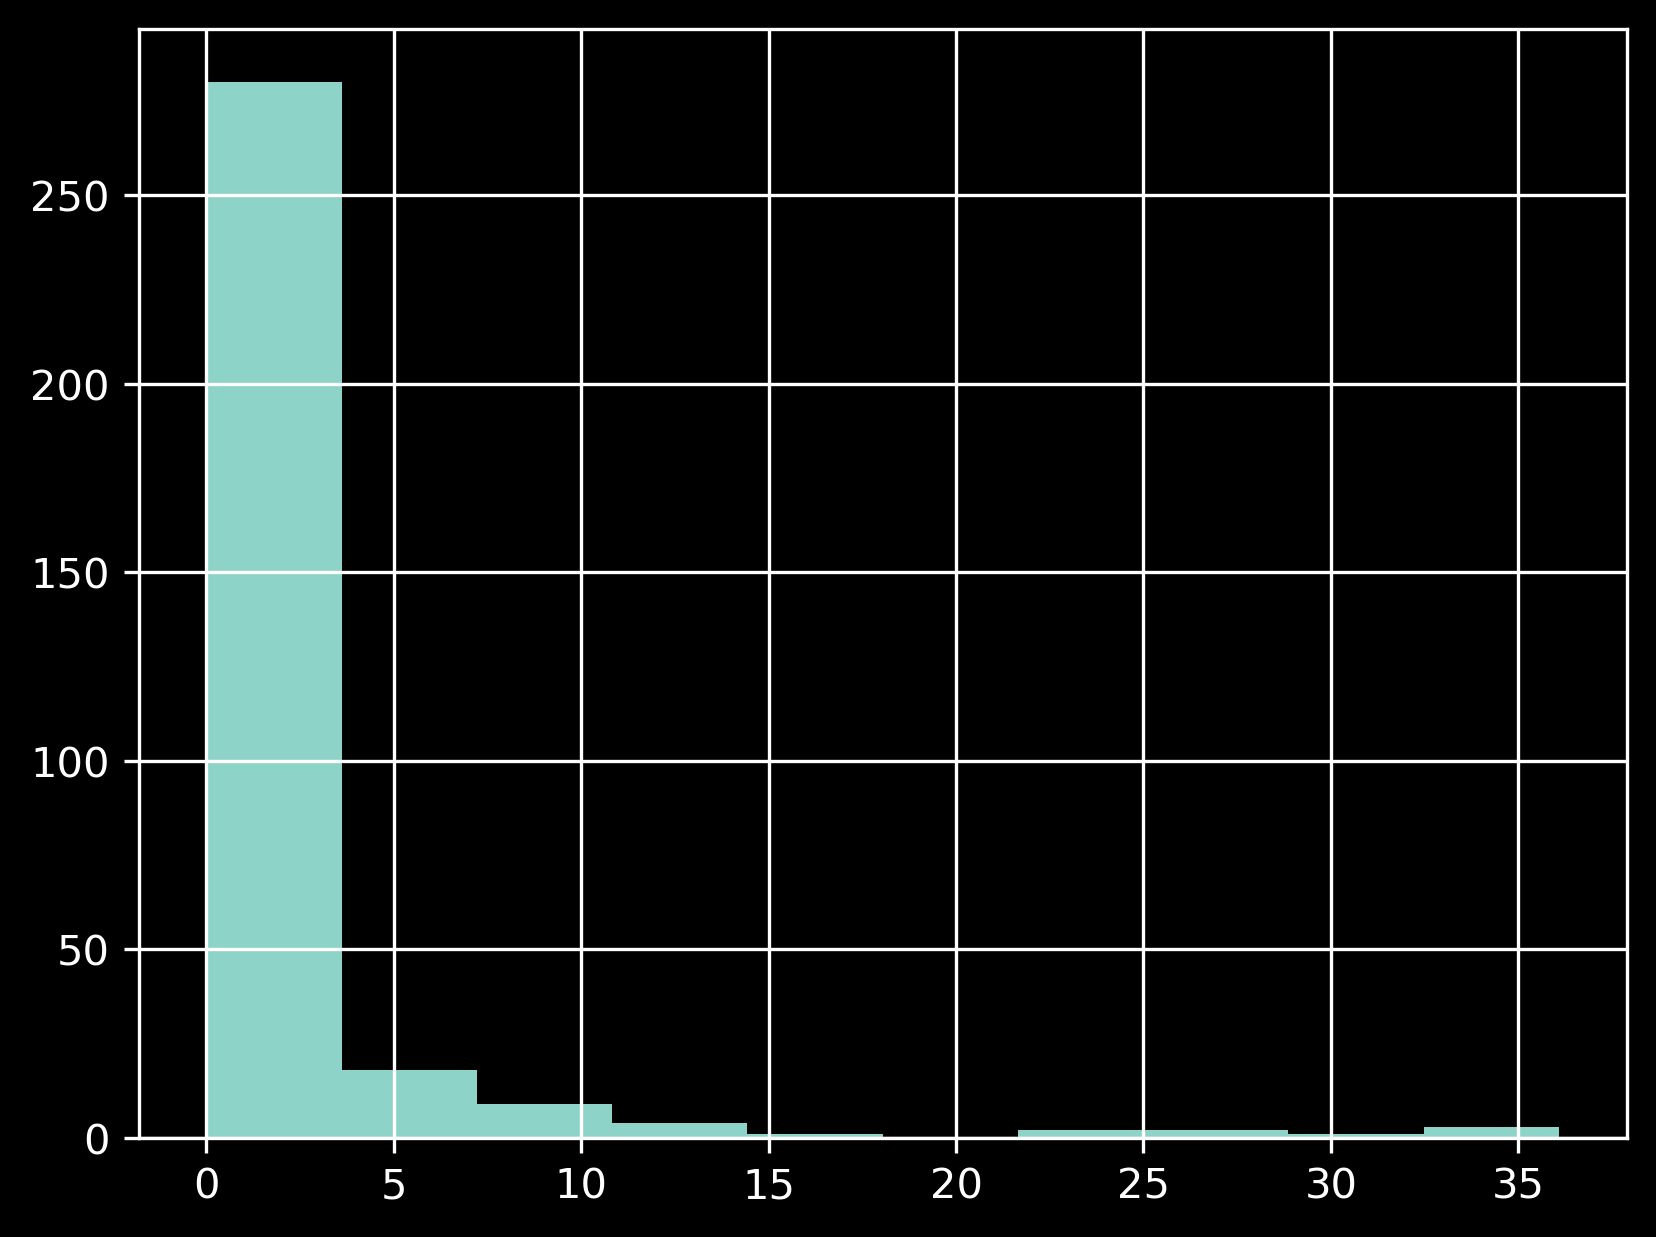

volcanic
max: 74.3407
mean: 6.906835625000001
median: 3.60785
min: 0.0


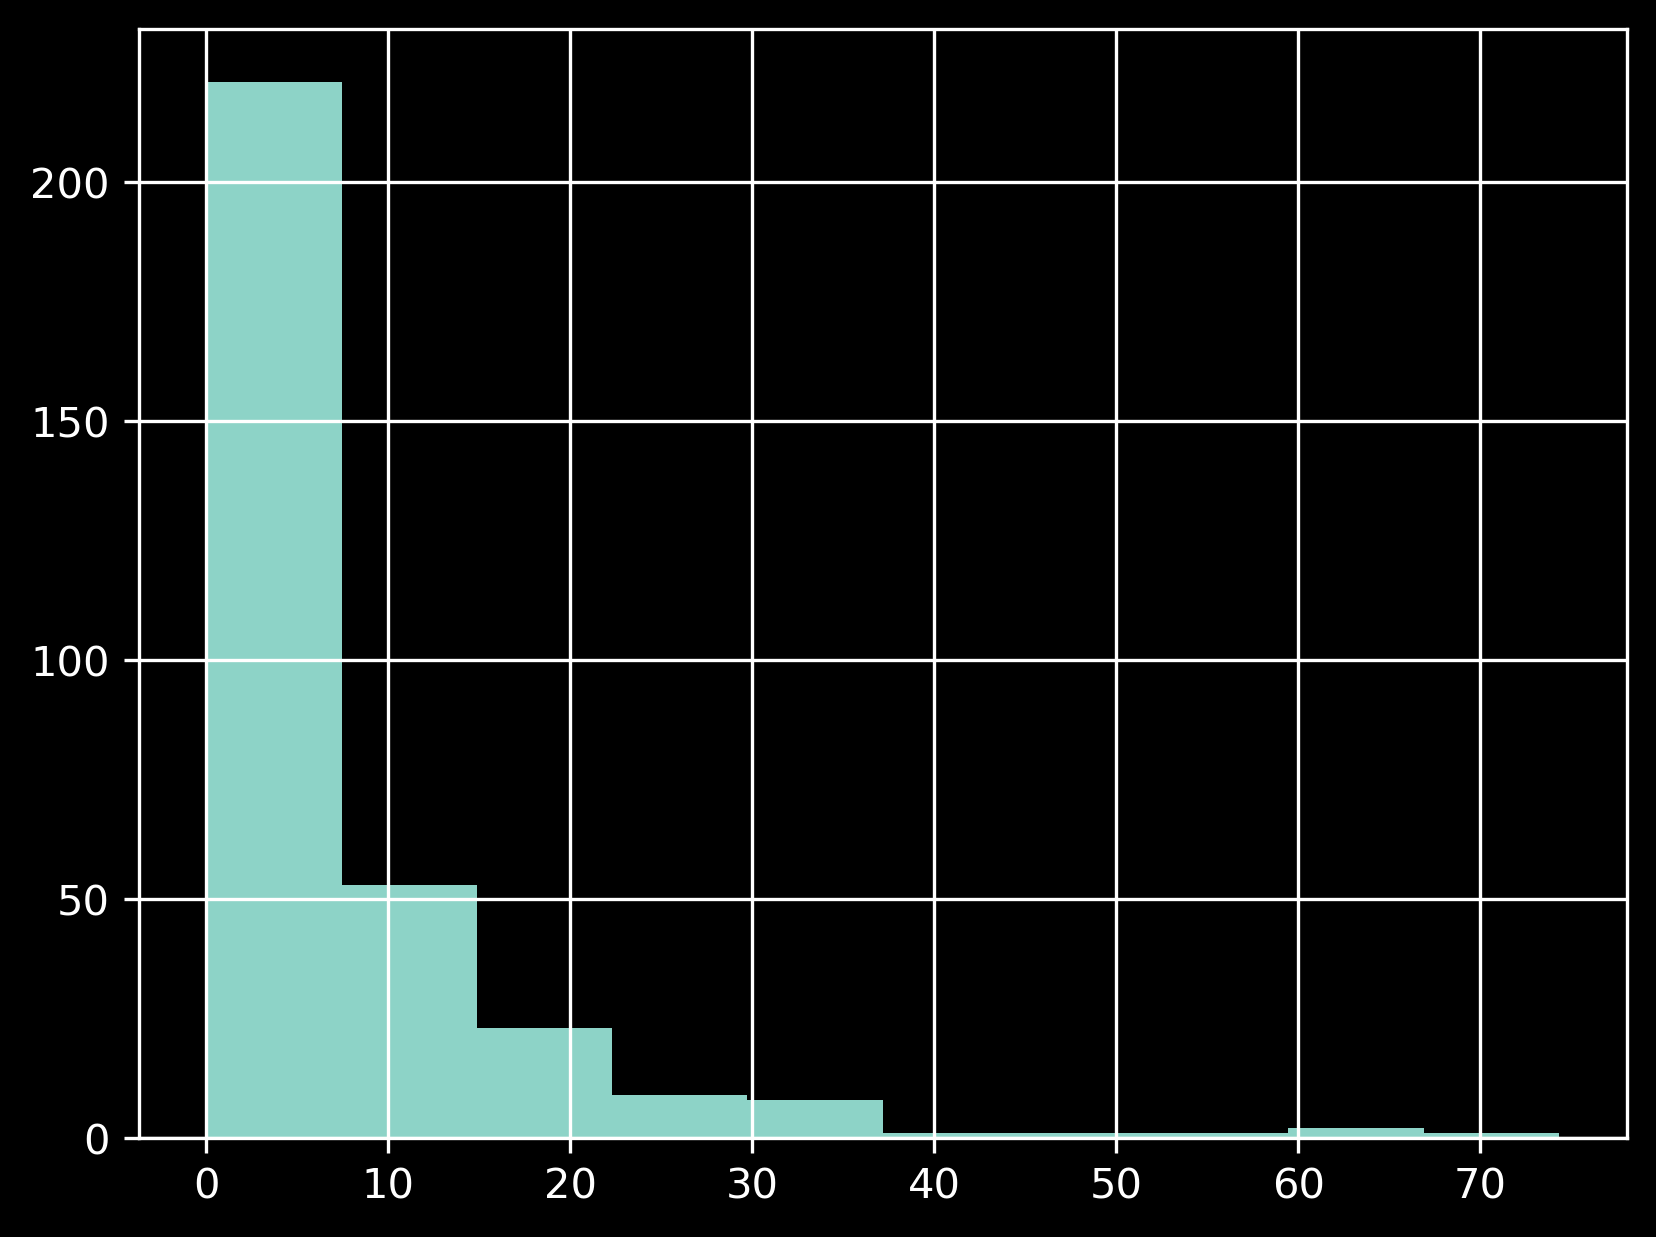

hypabyssal
max: 100.0
mean: 1.2939928124999998
median: 0.0
min: 0.0


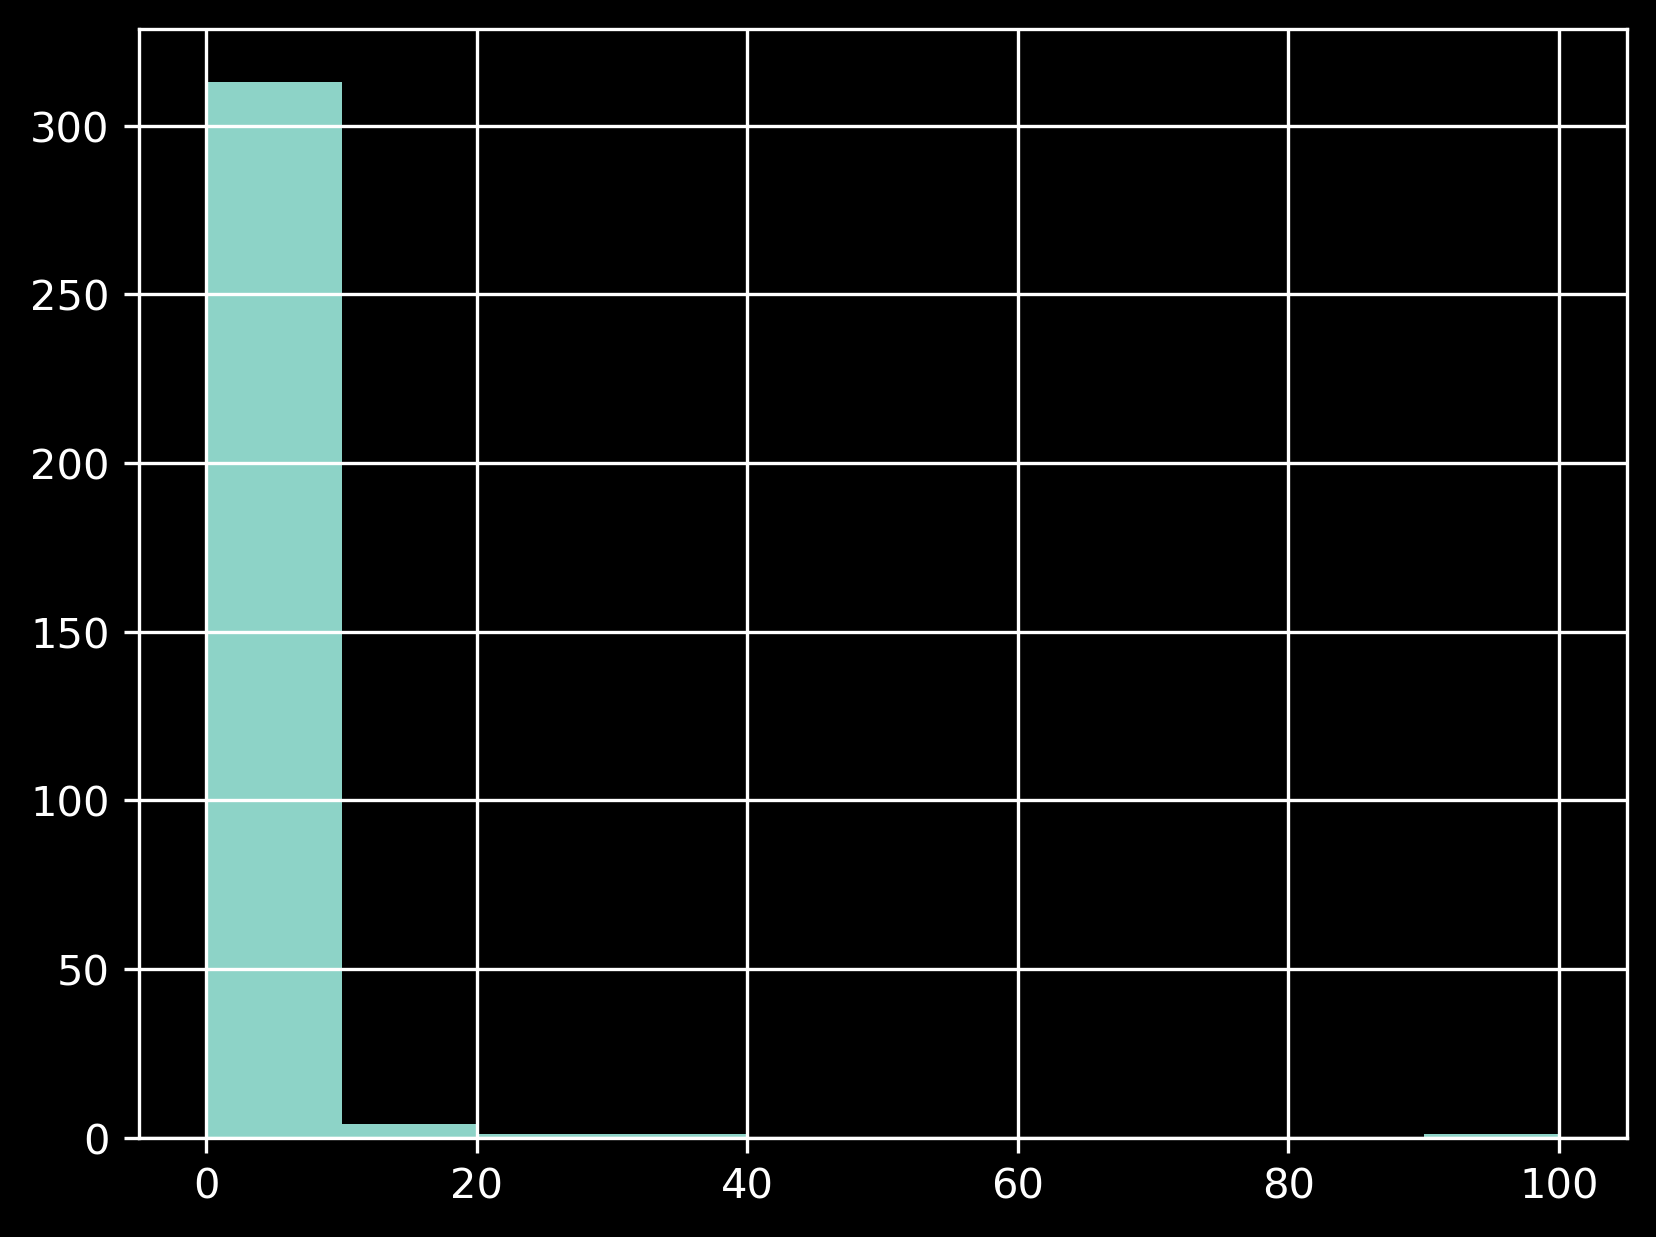

plutonic
max: 100.0
mean: 56.78896249999999
median: 60.5553
min: 0.0


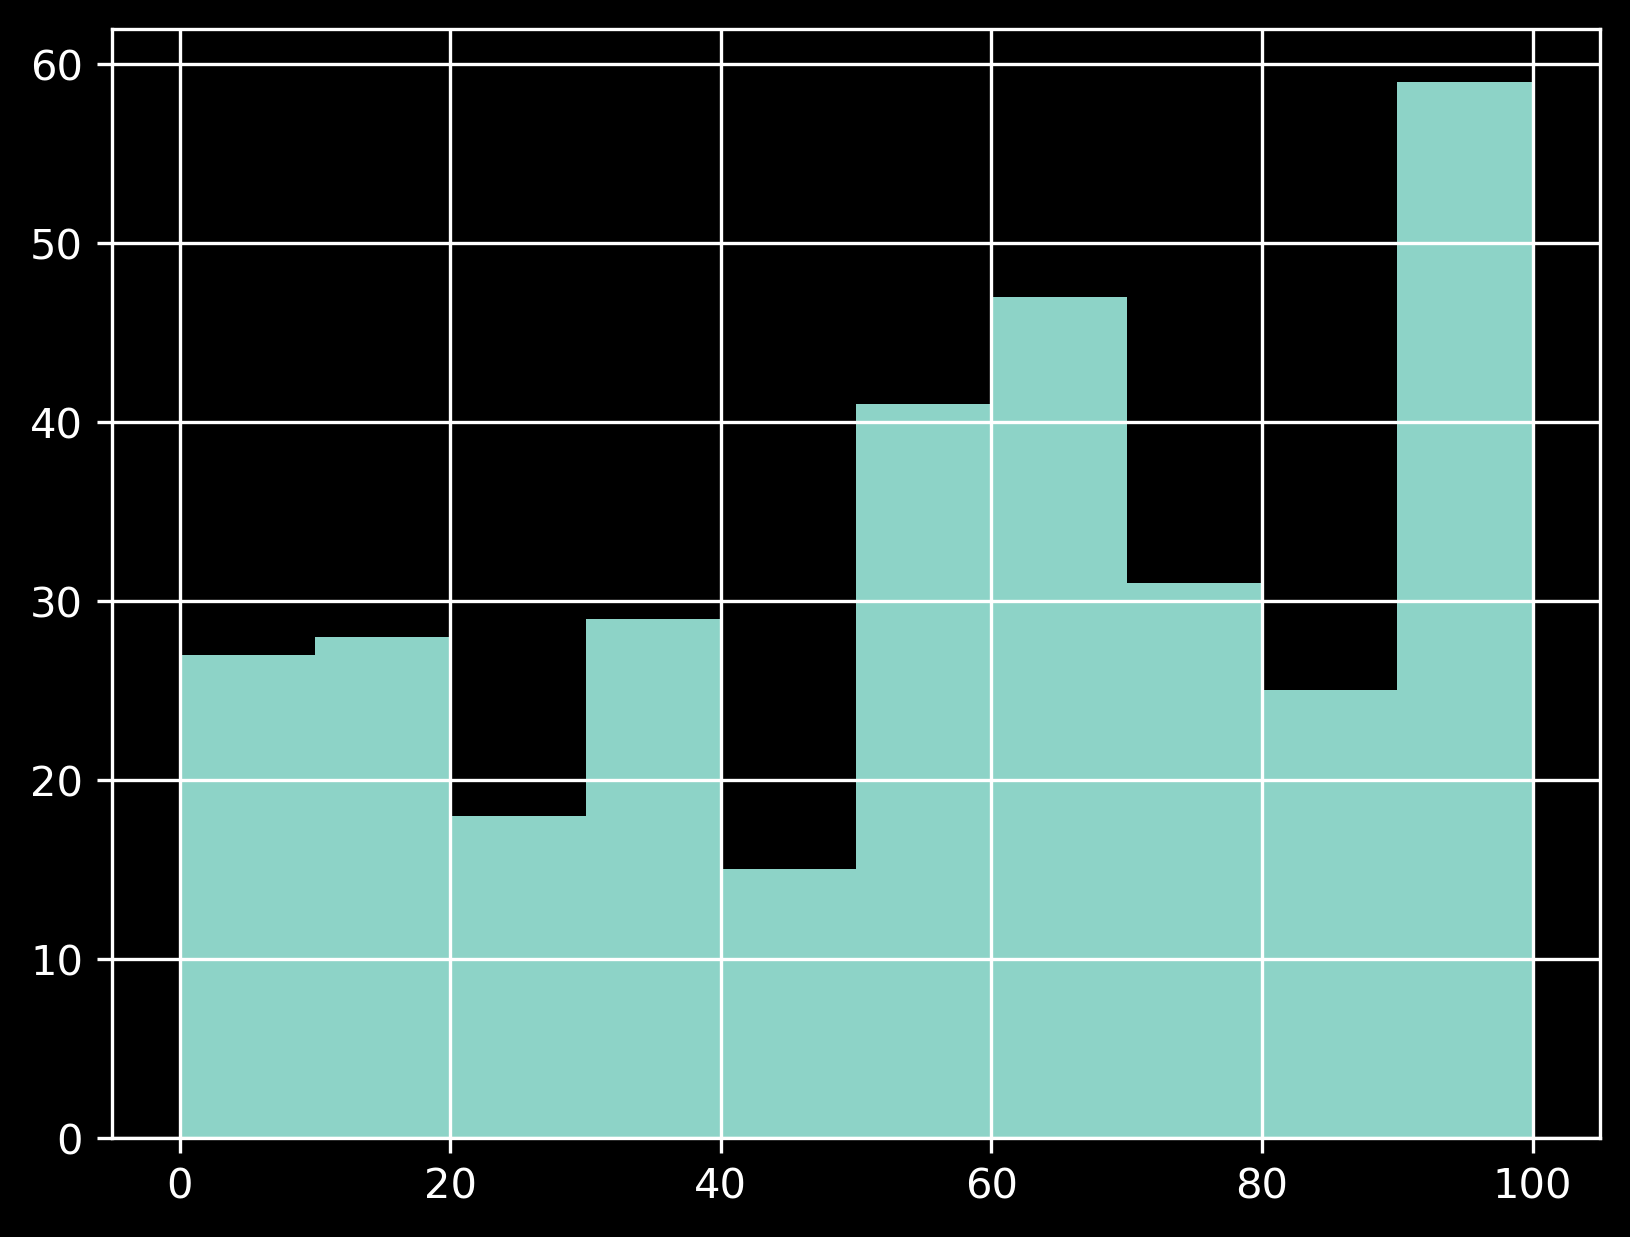

metamorphic
max: 100.0
mean: 33.019110312500004
median: 28.2101
min: 0.0


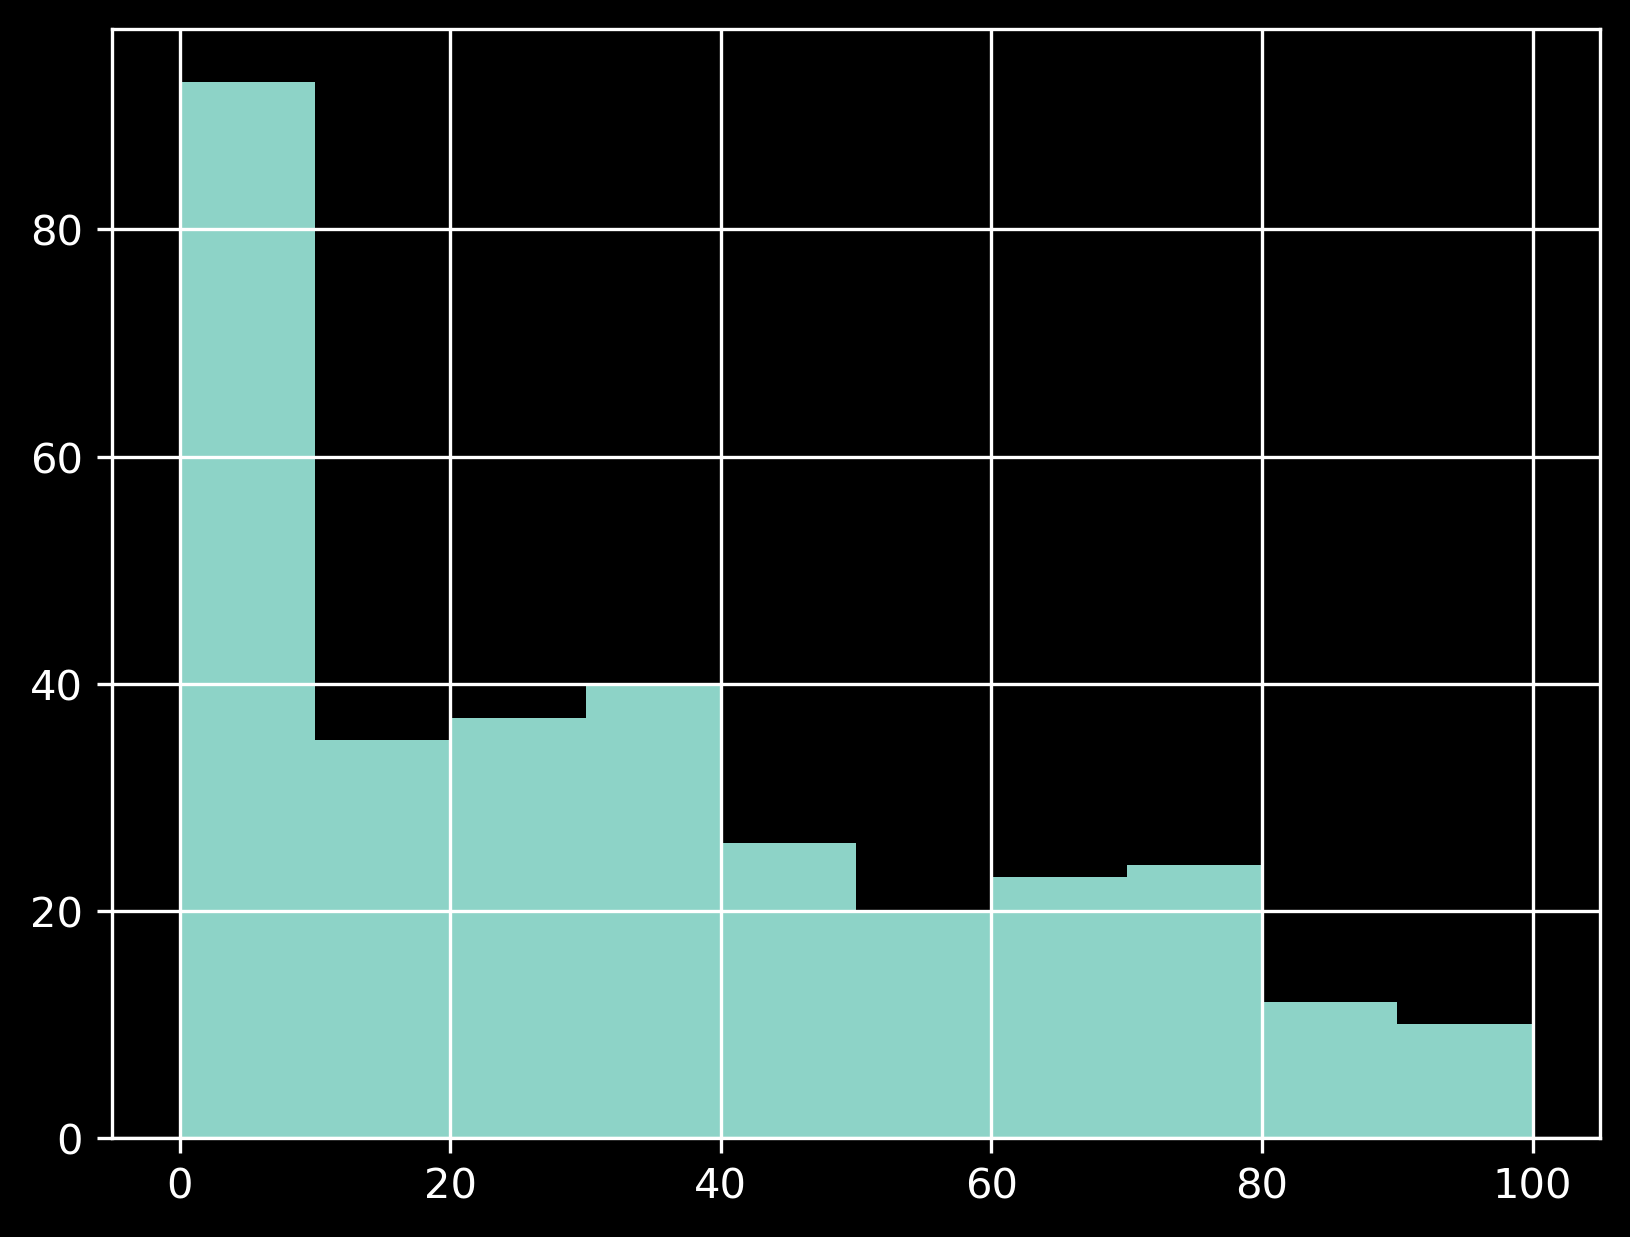

other_rock
max: 7.5649
mean: 0.1338709375
median: 0.0
min: 0.0


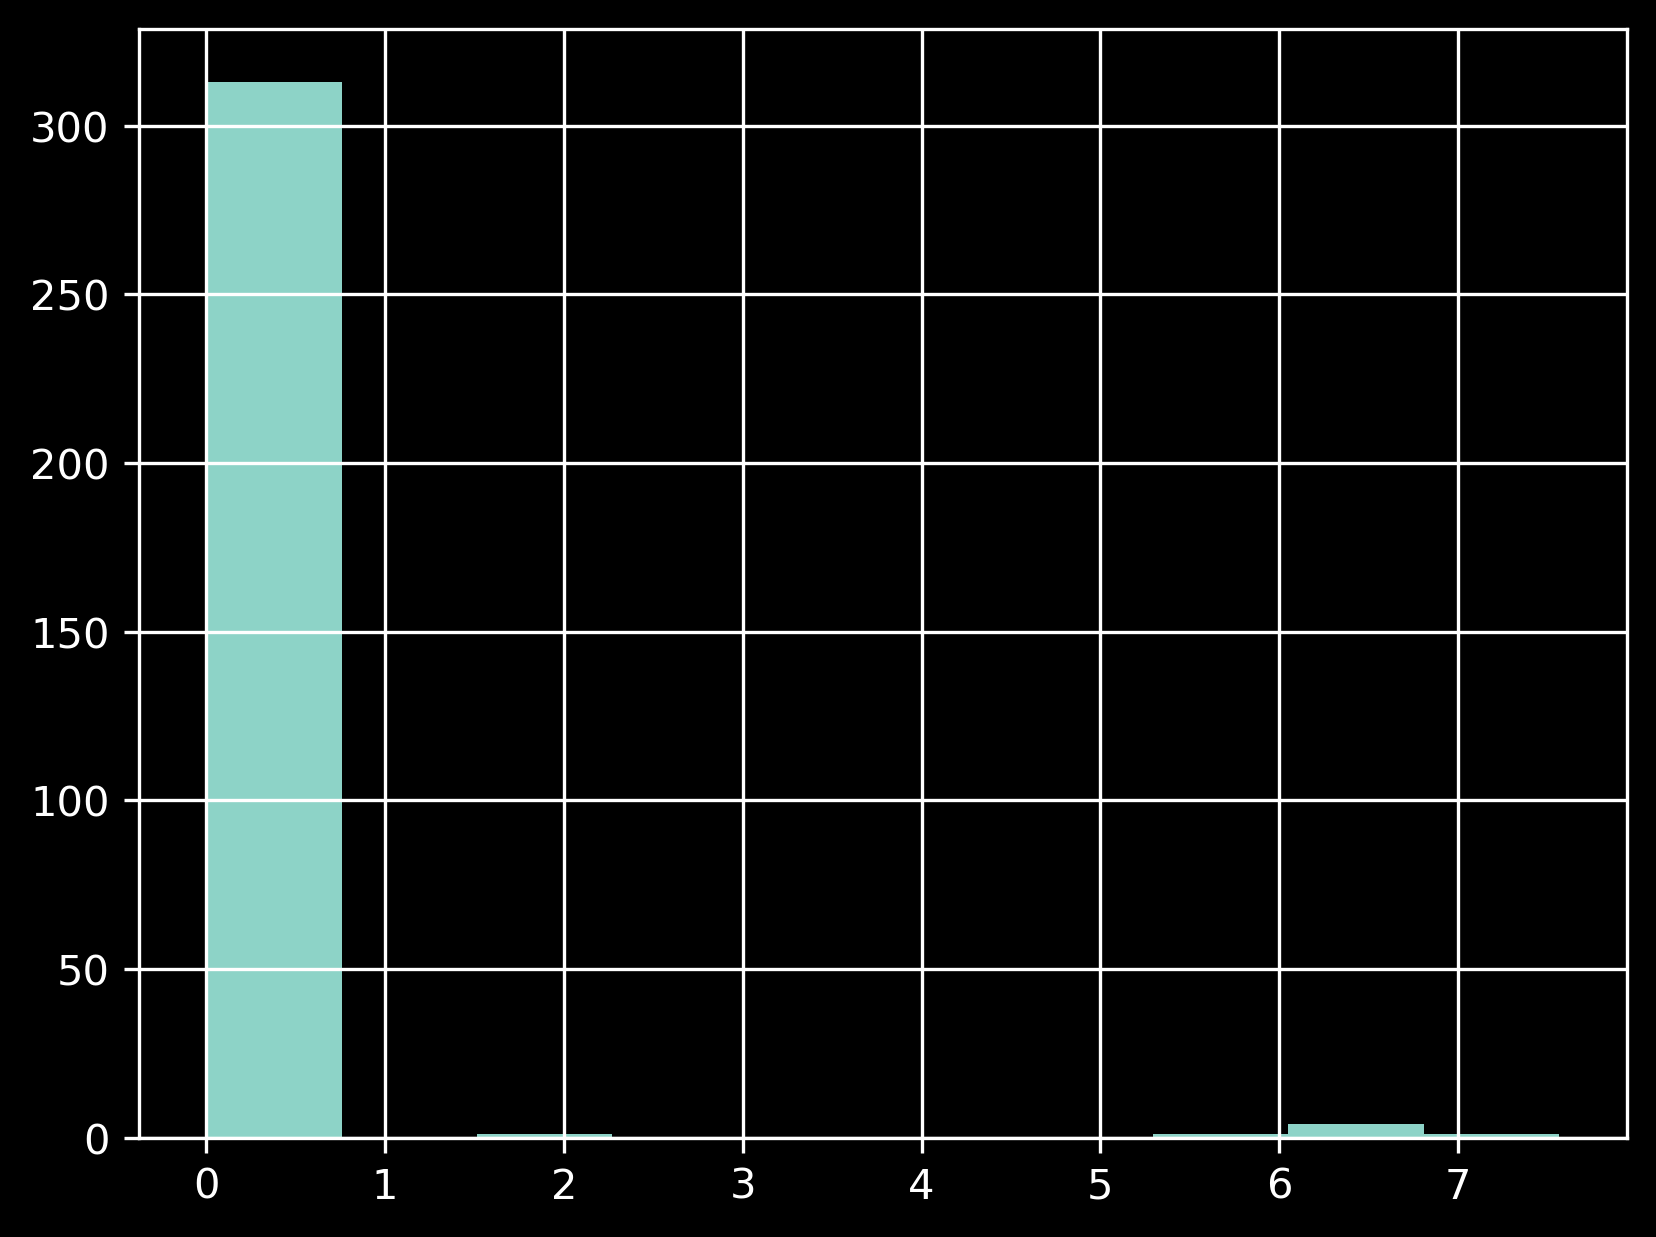

In [15]:
for rock_class in classes:
    print(rock_class)
    print(f'max: {catchments[f'{rock_class}_perc'].max()}')
    print(f'mean: {catchments[f'{rock_class}_perc'].mean()}')
    print(f'median: {catchments[f'{rock_class}_perc'].median()}')
    print(f'min: {catchments[f'{rock_class}_perc'].min()}')
    ax = catchments[f'{rock_class}_perc'].hist()
    plt.show()

In [16]:
catchments = catchments.set_index('gauge_id')

In [19]:
attributes = catchments.drop(['area', 'geometry'], axis=1)

In [20]:
attributes

,carbonate_sedimentary_perc,siliclastic_sedimentary_perc,volcanic_perc,hypabyssal_perc,plutonic_perc,metamorphic_perc,other_rock_perc
gauge_id,,,,,,,
996,0.0,0.0000,0.9640,5.3890,92.8083,0.8388,0.0
1003,0.0,9.7190,16.8545,0.1422,58.9784,14.3060,0.0
1008,0.0,3.8667,9.8430,0.0532,62.1058,24.1312,0.0
1009,0.0,3.7353,9.5086,0.0514,63.3934,23.3113,0.0
1012,0.0,3.2375,8.8844,0.0446,65.9664,21.8672,0.0
...,...,...,...,...,...,...,...
961,0.0,0.0000,0.1578,0.5822,32.7145,66.5454,0.0
964,0.0,0.0000,0.0000,0.0000,36.5544,63.4456,0.0
1369,0.0,0.0000,9.2665,0.0000,8.0436,82.6899,0.0


In [21]:
attributes.to_csv('/media/iielse/T9/CAMELS-FI_revision/lithology/CAMELS_FI_geology_attributes.csv')